# Projet 8

# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random
import numpy as np
from PIL import Image

On va commencer par explorer un seul fichier json que l'on va mettre dans un tableau. Chaque feature correspondra à une colonne du tableau. Une fois fait, on pourra généraliser avec tous les fichier .json de berlin.

In [2]:
df_1 = pd.read_json("data/P8_Cityscapes_gtFine_trainvaltest/gtFine/test/berlin/berlin_000000_000019_gtFine_polygons.json")
df_1

,imgHeight,imgWidth,objects
0,1024,2048,"{'label': 'ego vehicle', 'polygon': [[271, 102..."
1,1024,2048,"{'label': 'out of roi', 'polygon': [[0, 0], [2..."


In [3]:
df_1['objects'][0]['label']

'ego vehicle'

In [4]:
df_1['objects'][1]

{'label': 'out of roi',
 'polygon': [[0, 0],
  [2048, 0],
  [2048, 1024],
  [0, 1024],
  [0, 0],
  [5, 5],
  [5, 1019],
  [2043, 1019],
  [2043, 5],
  [5, 5]]}

## Transformation des classes
On ramène les 32 classes d'origine aux 8 catégories demandées pour l'entraînement du modèle.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# On charge un mask avec les id des différentes catégories (34 au total)
mask_path = 'data/P8_Cityscapes_gtFine_trainvaltest/gtFine/test/berlin/berlin_000000_000019_gtFine_labelIds.png'
mask = np.array(Image.open(mask_path))

# Dictionnaire pour passer des 34 classes aux 8 catégories de base
cat_dict = {
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0,   # void
    7: 1, 8: 1, 9: 1, 10: 1,                    # flat
    11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2,   # construction
    17: 3, 18: 3, 19: 3, 20: 3,                 # object
    21: 4, 22: 4,                               # nature
    23: 5,                                      # sky
    24: 6, 25: 6,                               # human
    26: 7, 27: 7, 28: 7, 29: 7, 30: 7, 31: 7, 32: 7, 33: 7  # vehicle
}

# Créer un nouveau mask vide de la même taille
new_mask = np.zeros_like(mask)

# On remplace pixel par pixel en utilisant numpy (plus rapide qu'une boucle for)
for old_val, new_val in cat_dict.items():
    new_mask[mask == old_val] = new_val


In [6]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
# Dictionnaire de conversion (comme vu dans le notebook)
cat_dict = {
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0,
    7: 1, 8: 1, 9: 1, 10: 1,
    11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2,
    17: 3, 18: 3, 19: 3, 20: 3,
    21: 4, 22: 4,
    23: 5,
    24: 6, 25: 6,
    26: 7, 27: 7, 28: 7, 29: 7, 30: 7, 31: 7, 32: 7, 33: 7
}

# Pour aller très vite sur des milliers d'images, on crée un tableau de correspondance 
# ("LUT" ou LookUp Table). C'est beaucoup plus rapide qu'une boucle 'for' sur chaque pixel !
mapping = np.zeros(256, dtype=np.uint8)
for k, v in cat_dict.items():
    mapping[k] = v

def process_file(in_path):
    # On sauvegarde avec un nouveau nom explicite pour ne pas écraser les fichiers originaux
    out_path = in_path.replace('labelIds.png', 'label8cat.png')
    
    # On passe si le fichier a déjà été converti
    if os.path.exists(out_path):
        return
    
    try:
        # 1. Ouvrir l'image
        mask = np.array(Image.open(in_path))
        # 2. Remplacer toutes les valeurs instantanément grâce au tableau de correspondance
        new_mask = mapping[mask]
        # 3. Sauvegarder la nouvelle image
        Image.fromarray(new_mask).save(out_path)
    except Exception as e:
        print(f"Erreur sur {in_path}: {e}")

# Lister absolument toutes les images labelIds dans le dossier data/ (train, val, test...)
all_files = glob.glob('data/P8_Cityscapes_gtFine_trainvaltest/gtFine/**/*_gtFine_labelIds.png', recursive=True)
print(f"Lancement de la conversion de {len(all_files)} images...")

# Lancer la boucle sur plusieurs processeurs en même temps pour aller très vite
with ThreadPoolExecutor() as ex:
    list(tqdm(ex.map(process_file, all_files), total=len(all_files)))

print("Conversion terminée avec succès !")


Lancement de la conversion de 5000 images...


  0%|                                                  | 0/5000 [00:00<?, ?it/s]

  2%|▉                                     | 124/5000 [00:00<00:04, 1191.26it/s]

  5%|█▉                                     | 244/5000 [00:00<00:05, 915.52it/s]

  7%|██▋                                    | 340/5000 [00:00<00:05, 836.66it/s]

...

 98%|█████████████████████████████████████▎| 4908/5000 [00:12<00:00, 254.24it/s]

 99%|█████████████████████████████████████▌| 4946/5000 [00:12<00:00, 280.25it/s]

100%|█████████████████████████████████████▊| 4976/5000 [00:13<00:00, 248.44it/s]

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 378.33it/s]

Conversion terminée avec succès !


## Vérification de la conversion
Assurons-nous que le script a bien fonctionné en vérifiant mathématiquement les classes d'un de nos nouveaux fichiers.

In [7]:
# Nombre d'images à vérifier au hasard
N_IMAGES_A_VERIFIER = 50

# Lister toutes les images converties disponibles
converted_files = glob.glob('data/P8_Cityscapes_gtFine_trainvaltest/gtFine/**/*_gtFine_label8cat.png', recursive=True)

# Sélectionner un échantillon aléatoire
echantillon = random.sample(converted_files, min(N_IMAGES_A_VERIFIER, len(converted_files)))

toutes_classes_originales = set()
toutes_classes_converties = set()

print(f"Vérification en cours sur {len(echantillon)} images aléatoires...")

for path_converted in echantillon:
    path_original = path_converted.replace('label8cat.png', 'labelIds.png')
    
    # Chargement des deux images
    mask_original = np.array(Image.open(path_original))
    mask_converted = np.array(Image.open(path_converted))
    
    # Mise à jour de l'ensemble (set) global avec les uniques de l'image
    toutes_classes_originales.update(np.unique(mask_original))
    toutes_classes_converties.update(np.unique(mask_converted))

print("\n--- RESULTATS SUR TOUT LE POOL D'IMAGES ---")
print("Classes présentes dans les images ORIGINALES (doit aller jusqu'à ~33) :")
print(sorted(list(toutes_classes_originales)))
print("\nClasses présentes dans les images CONVERTIES (ne doit contenir que des chiffres entre 0 et 7) :")
print(sorted(list(toutes_classes_converties)))


Vérification en cours sur 50 images aléatoires...



--- RESULTATS SUR TOUT LE POOL D'IMAGES ---
Classes présentes dans les images ORIGINALES (doit aller jusqu'à ~33) :
[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26), np.uint8(27), np.uint8(28), np.uint8(29), np.uint8(30), np.uint8(31), np.uint8(32), np.uint8(33)]

Classes présentes dans les images CONVERTIES (ne doit contenir que des chiffres entre 0 et 7) :
[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7)]


## Visualisation des Images et Labels (EDA)
Affichage côte à côte de l'image brute, du mask coloré, du mask distribué sur les 8 grandes catégories, et l'histogramme des classes.

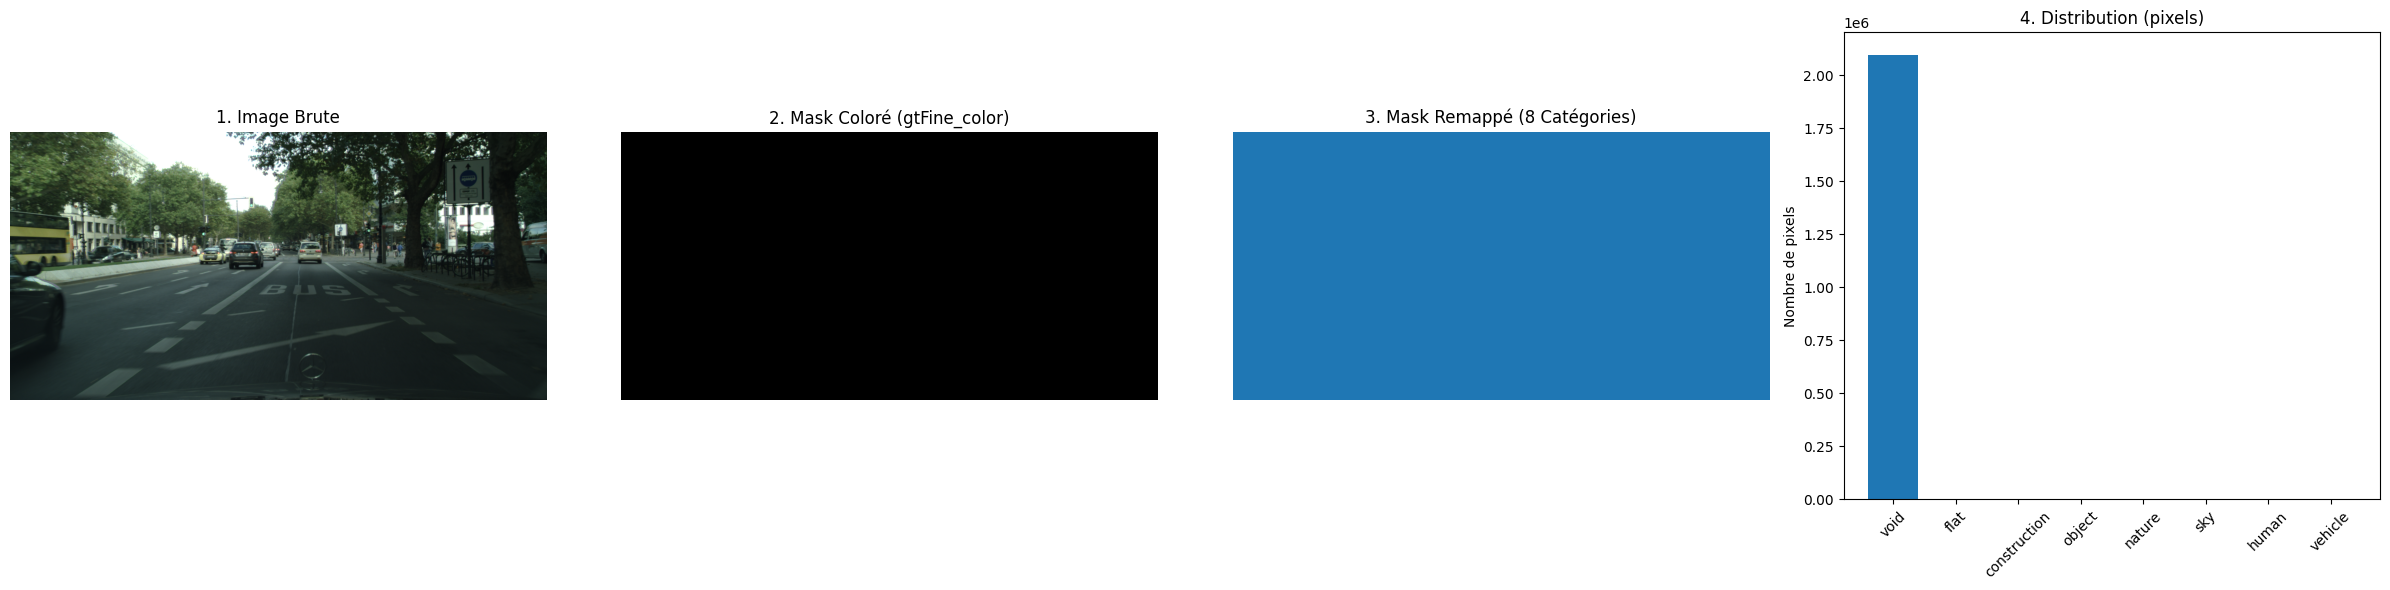

In [8]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Mapping des 34 classes Cityscapes vers les 8 catégories
LABEL_TO_CATEGORY = {
    0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0,   # void
    7: 1, 8: 1, 9: 1, 10: 1,                    # flat
    11: 2, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2,   # construction
    17: 3, 18: 3, 19: 3, 20: 3,                 # object
    21: 4, 22: 4,                               # nature
    23: 5,                                      # sky
    24: 6, 25: 6,                               # human
    26: 7, 27: 7, 28: 7, 29: 7, 30: 7, 31: 7, 32: 7, 33: 7  # vehicle
}

# Fonction pour remapper le mask
def remap_mask(mask):
    mask_copy = np.copy(mask)
    for original_id, mapped_id in LABEL_TO_CATEGORY.items():
        mask_copy[mask == original_id] = mapped_id
    # Gérer les ids hors dictionnaire
    mask_copy[~np.isin(mask, list(LABEL_TO_CATEGORY.keys()))] = 0
    return mask_copy

def plot_eda(city="berlin", image_idx=0):
    gt_dir = f"data/P8_Cityscapes_gtFine_trainvaltest/gtFine/test/{city}"
    img_dir = f"data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/test/{city}"
    
    json_files = sorted(glob.glob(os.path.join(gt_dir, "*_gtFine_polygons.json")))
    if not json_files:
        print(f"Aucune image trouvée pour {city} dans {gt_dir}")
        return
        
    prefix = json_files[image_idx].replace('_gtFine_polygons.json', '')
    color_path = prefix + "_gtFine_color.png"
    label_path = prefix + "_gtFine_labelIds.png"
    
    raw_filename = prefix.split('/')[-1].replace('_gtFine', '') + '_leftImg8bit.png'
    raw_path = os.path.join(img_dir, raw_filename)
        
    try:
        color_mask = Image.open(color_path)
        label_mask = np.array(Image.open(label_path))
    except Exception as e:
        print(f"Erreur de chargement: {e}")
        return
        
    remapped_mask = remap_mask(label_mask)
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # 1. Image Brute
    if os.path.exists(raw_path):
        axes[0].imshow(Image.open(raw_path))
        axes[0].set_title("1. Image Brute")
    else:
        axes[0].text(0.5, 0.5, 'Image Brute non trouvée\n', ha='center', va='center', fontsize=12)
        axes[0].set_title("1. Image Brute (Manquante)")
    axes[0].axis('off')
    
    # 2. Mask Coloré
    axes[1].imshow(color_mask)
    axes[1].set_title("2. Mask Coloré (gtFine_color)")
    axes[1].axis('off')
    
    # 3. Mask Remappé
    img_cmap = axes[2].imshow(remapped_mask, cmap='tab10', vmin=0, vmax=7)
    axes[2].set_title("3. Mask Remappé (8 Catégories)")
    axes[2].axis('off')
    
    # 4. Distribution des classes
    unique, counts = np.unique(remapped_mask, return_counts=True)
    hist_counts = np.zeros(8)
    for u, c in zip(unique, counts):
        if 0 <= u < 8:
            hist_counts[int(u)] = c
            
    categories = ['void', 'flat', 'construction', 'object', 'nature', 'sky', 'human', 'vehicle']
    colors = plt.cm.tab10(np.linspace(0, 1, 10))[:8]
    axes[3].bar(categories, hist_counts, color=colors)
    axes[3].set_title("4. Distribution (pixels)")
    axes[3].set_ylabel("Nombre de pixels")
    axes[3].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Tester l'affichage sur la première image du test set de Berlin
plot_eda('berlin', 0)


## Conclusion de l'Étape Exploratoire et Transition

Maintenant que la partie exploratoire (EDA) est terminée et validée expérimentalement, nous avons une très bonne vision de la complexité du jeu de données (déséquilibre de classes flagrant, volumes importants). L'objectif initial était de comprendre la structure de base afin d'industrialiser notre chaîne de traitement.

Conformément à la méthodologie du projet, le travail s'oriente vers deux grandes approches :

### 1. La partie de Recherche (Phase 2 du guide)
Avant de coder aveuglement, la prochaine grande étape est l'élaboration de la stratégie théorique :
*   **Choix de Métrique :** L'accuracy classique n'est pas fiable sur des datasets déséquilibrés. Nous opterons donc pour la compréhension et le calcul du **mIoU** (mean Intersection over Union).
*   **Fonction de Perte (Loss) :** Mêmes causes, mêmes conséquences : minimiser une perte binaire simple ne paiera pas. Nous regarderons les pertes combinées (*Dice Loss* et *Categorical Cross-Entropy*, ou *Focal Loss*).
*   **Revue d'Architectures :** Il sera nécessaire de justifier notre approche vis-à-vis d'architectures sémantiques robustes (FCN classiques, U-Net pour la stabilité, et éventuellement DeepLab v3+).

### 2. Le défi de l'Ingénierie de Données (Phase 3 & 4 du guide)
Afin de poursuivre vers TensorFlow, nos images sont tellement massives (1024x2048) et nombreuses (~5000) que nous allons faire face aux limites physiques du GPU/RAM (Out-Of-Memory Error). Il est techniquement impossible de générer un jeu de données stationnaire.
Il faudra coder un Pipeline de distribution qui s'occupe de traiter, charger et redimensionner l'**imagerie à la Volée** lors de l'entraînement, via l'héritage d'un modèle Keras (Data Generator). C'est le but du prochain Notebook !